In [38]:
import pandas as pd
import numpy as np
import re

In [39]:
df1_task2 = pd.read_csv("../data/raw/chillies_IELTS_evaluations_all.csv")
df2_task2 = pd.read_csv("../data/raw/chillies_IELTS-writing-task-2-evaluation_all.csv")
df3_task2 = pd.read_csv("../data/raw/nlpatunt_D_Ielts_Writing_Task_2_Dataset_all.csv")
df4_task2 = pd.read_csv("../data/raw_split/task2_merged.csv")

In [40]:
print(df1_task2.shape, df2_task2.shape, df3_task2.shape, df4_task2.shape)

(10407, 4) (10324, 4) (10324, 5) (711, 8)


In [41]:
df1_task2

,prompt,essay,evaluation,band
0,Young people who commit crimes should be treat...,Deciding to choose among the potential ways of...,## Task Achievement:\nThe candidate has adequa...,5\r\r\r\r\r\r\r\r\r\r\r\r\r\r
1,Young people who commit crimes should be treat...,"In this modern era, youngsters who commit offe...",## Task Achievement:\n- The candidate addresse...,6\r\r\r\r\r\r\r\r\r\r\r\r\r\r
2,Young people who commit crimes should be treat...,"In this modern era, youngsters who commit offe...",### Task Achievement:\n- The candidate has par...,4\r\r\r\r\r\r\r\r\r\r\r\r\r\r
3,Young people who commit crimes should be treat...,It is suggested that punishments for immature ...,## Task Achievement:\n- The candidate has succ...,8\r\r\r\r\r\r\r\r\r\r\r\r\r\r
4,Young people who commit crimes should be treat...,There is a controversial dispute about whether...,## Task Achievement:\n- The candidate has addr...,6\r\r\r\r\r\r\r\r\r\r\r\r\r\r
...,...,...,...,...
10402,Some people think that the main purpose of sch...,"It is argued that, the principle goal of schoo...",## Task Achievement:\n- The candidate has part...,7
10403,The increase in the production of consumer goo...,"In recent times, we have witnessed a significa...",## Task Achievement:\nThe candidate has succes...,6\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r
10404,Some people believe that what children watch o...,Nowadays tv plays a major role in our life. It...,## Task Achievement:\n- The candidate has adeq...,5\r\n\r\n\r\n\r\n\r\n\r
10405,Some people think news has no connection to pe...,"In today’s society, people have various viewpo...",## Task Achievement:\n\n- The candidate has ad...,6\r\n\r\n\r\n\r\n\r


In [42]:
df2_task2

,prompt,essay,evaluation,band
0,Interviews form the basic criteria for most la...,It is believed by some experts that the tradit...,**Task Achievement: [7]**\nThe essay effective...,7.5\n\n\n\n\n\r\r\r\r\r\r\r\r\r\r\r\r\r
1,Interviews form the basic selecting criteria f...,Nowadays numerous huge firms allocate an inter...,**Task Achievement:** 5.0\n- The candidate has...,5.0\n\n\n\n\n\r\r\r\r\r\r\r\r\r\r\r\r\r
2,Interview form the basic selection criteria fo...,The interview section is the most vital part o...,## Task Achievement:\n- The candidate has effe...,5.5\n\n\n\n\n\r\r\r\r\r\r\r\r\r\r\r\r\r
3,Interviews form the basic selection criteria f...,It is argued that the best method to recruit e...,## Task Achievement:\n- The candidate has adeq...,5.5\n\n\n\n\n\r\r\r\r\r\r\r\r\r\r\r\r\r
4,Interviews from the basic selecting criteria f...,Nowadays many companies conduct interviews bef...,**Task Achievement:**\n\nThe essay adequately ...,4\n\n\n\n\n\r\r\r\r\r\r\r\r\r\r\r\r\r
...,...,...,...,...
10319,"As well as making money, businesses also have ...",The role of companies is to produce all the go...,**Task Achievement:** 6\n\nThe essay effective...,6
10320,"As well as making money, businesses also have ...",Although earning money is one of the most impo...,**Task Achievement:**\n\n- The essay adequatel...,7.5
10321,"As well as making money, businesses also have ...",IIt is argued by many people that companies ha...,**Task Achievement: 4**\n\nThe essay addresses...,5
10322,"As well as making money, businesses also have ...","In this modern era , everyone needs money for ...",## Task Achievement:\n- The candidate has adeq...,4


In [43]:
df3_task2

,ID,prompt,essay,evaluation,band_score
0,1,Many people believe that modern music can have...,Music is a treatment for mind of people.There ...,### Task Achievement:\n- The essay somewhat ad...,<4\r\r\r\r
1,2,Some people think that the main purpose of sch...,Some people are of the opinion that the primar...,## Task Achievement:\n- The candidate has effe...,7\r
2,3,Historical objects should be brought back thei...,The thing which has an extra ordinary value in...,## **Task Achievement:**\n\n- The candidate ha...,<4\r\r\r\r\r
3,4,"As well as making money, businesses should als...",It is widely believed that companies should no...,## Task Achievement:\n- The candidate has effe...,6
4,5,The increase in the production of consumer goo...,The increasing desire for consumer goods today...,**Task Achievement: 7**\n\nThe candidate has e...,8\n\n\n\n\n\r\r\r\r\r\r\r\r\r\r\r\r\r
...,...,...,...,...,...
10319,487,"As well as making money, businesses also have ...",The role of companies is to produce all the go...,**Task Achievement:** 6\n\nThe essay effective...,NaN
10320,488,"As well as making money, businesses also have ...",Although earning money is one of the most impo...,**Task Achievement:**\n\n- The essay adequatel...,NaN
10321,489,"As well as making money, businesses also have ...",IIt is argued by many people that companies ha...,**Task Achievement: 4**\n\nThe essay addresses...,NaN
10322,490,"As well as making money, businesses also have ...","In this modern era , everyone needs money for ...",## Task Achievement:\n- The candidate has adeq...,NaN


In [44]:
df4_task2

,Question,Essay,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Examiner_Comment
0,A country becomes more interesting and develop...,A nation becomes more interesting and advance ...,NaN,NaN,NaN,NaN,7.0,NaN
1,A country becomes more interesting and develop...,It is belived that countries are developing fa...,NaN,NaN,NaN,NaN,6.0,NaN
2,A country becomes more interesting and develop...,Some people believe that having a population w...,NaN,NaN,NaN,NaN,7.5,NaN
3,A country becomes more interesting and develop...,There are people who believe that the mixture ...,NaN,NaN,NaN,NaN,6.5,NaN
4,A country becomes more interesting and develop...,There are some beliefs that when there is a mi...,NaN,NaN,NaN,NaN,7.5,NaN
...,...,...,...,...,...,...,...,...
706,should unpaid community work be mandatory in h...,Some people believe that unpaid community serv...,NaN,NaN,NaN,NaN,8.0,NaN
707,« Previous,Nowadays celebrities earn more money than poli...,NaN,NaN,NaN,NaN,8.0,NaN
708,‘Failure is proof that the desire wasn’t stron...,"Failure is what nobody wish for, but it could ...",NaN,NaN,NaN,NaN,7.0,NaN
709,‘Failure is proof that the desire wasn’t stron...,"Generally, in our real lives, failure and succ...",NaN,NaN,NaN,NaN,6.5,NaN


In [45]:
def extract_scores(text):

    if pd.isna(text) or not isinstance(text, str):
        return {}

    scores = {}

    # 1. NORMALIZE LOW SCORES

    def normalize_low_scores(match):
        return match.group(1)

    low_score_pattern = r"(?i)(?:below|under|less than|<)\s*(\d(?:\.[05])?)"
    text = re.sub(low_score_pattern, normalize_low_scores, text)

    clean_text = text.replace("__", "").replace("**", "")

    # 2. DEFINE SECTION HEADERS

    section_patterns = {
        "Task_Response": r"(?:Task Achievement|Task Response)",
        "Coherence_Cohesion": r"(?:Coherence and Cohesion|Coherence)",
        "Lexical_Resource": r"(?:Lexical Resource|Vocabulary)",
        "Range_Accuracy": r"(?:Grammatical Range and Accuracy|Grammar)",
        "Overall": r"(?:Overall Band Score|Overall)"
    }

    # 3. EXTRACT PER SECTION

    for key, pattern in section_patterns.items():

        # PLAN 0: SCORE IN HEADER
        # ## Task Achievement (7)

        header_pattern = rf"(?i)#+\s*{pattern}\s*[\(:]\s*(\d(?:\.[05])?)"
        m_header = re.search(header_pattern, clean_text)

        if m_header:
            scores[key] = float(m_header.group(1))
            continue

        # PLAN 0.5: Suggested Band Score
        # Suggested Band Score (Task Achievement): 7

        suggested_header = rf"Suggested\s+Band\s+Score\s*\(\s*{pattern}\s*\)\s*:\s*(\d(?:\.[05])?)"
        m_suggest_header = re.search(suggested_header, clean_text, re.I)

        if m_suggest_header:
            scores[key] = float(m_suggest_header.group(1))
            continue

        # Task Achievement: [7]
        # Task Achievement: 7

        header_inline = rf"(?i){pattern}\s*:\s*\[?(\d(?:\.[05])?)\]?"
        m_inline = re.search(header_inline, clean_text)

        if m_inline:
            scores[key] = float(m_inline.group(1))
            continue

        # PLAN 1: SPLIT SECTION CONTENT

        section_regex = rf"(?i)(?:#+\s*{pattern}.*?:?)(.*?)(?=\n#+\s*(?:Task Achievement|Task Response|Coherence and Cohesion|Coherence|Lexical Resource|Vocabulary|Grammatical Range and Accuracy|Grammar|Overall Band Score|Overall)|\Z)"

        m_section = re.search(section_regex, clean_text, re.S)

        if m_section:
            section_text = m_section.group(1)
        else:
            section_text = clean_text

        # PLAN 2: Explicit band mention

        pattern1 = r"(?:Band|Score|:|\(|\[)\s*(\d(?:\.[05])?)\b"
        m1 = re.search(pattern1, section_text, re.I)

        if m1:
            scores[key] = float(m1.group(1))
            continue

        # PLAN 3: Suggested band score

        pattern2 = r"suggested\s+(?:overall\s+)?band\s+score\s*(?:is|of|:)?\s*(\d(?:\.[05])?)"
        m2 = re.search(pattern2, section_text, re.I)

        if m2:
            scores[key] = float(m2.group(1))
            continue

        # PLAN 4: Narrative format

        pattern3 = r"received\s+(?:a\s+)?(\d(?:\.[05])?)\s+for"
        m3 = re.search(pattern3, section_text, re.I)

        if m3:
            scores[key] = float(m3.group(1))
            continue

        # PLAN 5: Fallback

        nums = re.findall(r"\b\d(?:\.[05])?\b", section_text)

        if nums:
            scores[key] = float(nums[-1])

    return scores

In [46]:
def build_from_raw(df):

    return pd.DataFrame({
        "Question": df.get("prompt"),
        "Essay": df.get("essay"),
        "Examiner_Comment": df.get("evaluation"),
        "Overall": pd.to_numeric(df.get("band"), errors='coerce')
    })


df1_std = build_from_raw(df1_task2)
df2_std = build_from_raw(df2_task2)
df3_std = build_from_raw(df3_task2)

In [47]:
df4_std = pd.DataFrame({
    "Question": df4_task2.get("Question"),
    "Essay": df4_task2.get("Essay"),
    "Task_Response": df4_task2.get("Task_Response"),
    "Coherence_Cohesion": df4_task2.get("Coherence_Cohesion"),
    "Lexical_Resource": df4_task2.get("Lexical_Resource"),
    "Range_Accuracy": df4_task2.get("Range_Accuracy"),
    "Overall": pd.to_numeric(df4_task2.get("Overall"), errors='coerce'),
    "Examiner_Comment": df4_task2.get("Examiner_Comment"),
})

In [48]:
df_raw_task2 = pd.concat(
    [df1_std, df2_std, df3_std, df4_std],
    ignore_index=True
)

print("Merged raw shape:", df_raw_task2.shape)

Merged raw shape: (31766, 8)


In [49]:
CRITERIA = [
    "Task_Response",
    "Coherence_Cohesion",
    "Lexical_Resource",
    "Range_Accuracy"
]

In [50]:
df_raw_task2

,Question,Essay,Examiner_Comment,Overall,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy
0,Young people who commit crimes should be treat...,Deciding to choose among the potential ways of...,## Task Achievement:\nThe candidate has adequa...,5.0,NaN,NaN,NaN,NaN
1,Young people who commit crimes should be treat...,"In this modern era, youngsters who commit offe...",## Task Achievement:\n- The candidate addresse...,6.0,NaN,NaN,NaN,NaN
2,Young people who commit crimes should be treat...,"In this modern era, youngsters who commit offe...",### Task Achievement:\n- The candidate has par...,4.0,NaN,NaN,NaN,NaN
3,Young people who commit crimes should be treat...,It is suggested that punishments for immature ...,## Task Achievement:\n- The candidate has succ...,8.0,NaN,NaN,NaN,NaN
4,Young people who commit crimes should be treat...,There is a controversial dispute about whether...,## Task Achievement:\n- The candidate has addr...,6.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
31761,should unpaid community work be mandatory in h...,Some people believe that unpaid community serv...,NaN,8.0,None,NaN,NaN,NaN
31762,« Previous,Nowadays celebrities earn more money than poli...,NaN,8.0,None,NaN,NaN,NaN
31763,‘Failure is proof that the desire wasn’t stron...,"Failure is what nobody wish for, but it could ...",NaN,7.0,None,NaN,NaN,NaN
31764,‘Failure is proof that the desire wasn’t stron...,"Generally, in our real lives, failure and succ...",NaN,6.5,None,NaN,NaN,NaN


In [51]:
df_raw_task2.duplicated(subset=["Essay"]).sum()

np.int64(21984)

In [52]:
parsed = df_raw_task2["Examiner_Comment"].apply(extract_scores)
parsed_df = pd.DataFrame(parsed.tolist())

parsed_df.head(1000)

,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall
0,7.0,7.0,6.5,6.5,6.5
1,7.0,7.0,7.0,7.0,7.0
2,6.0,5.5,5.5,5.0,5.5
3,7.5,8.0,7.0,7.5,7.5
4,6.5,6.0,6.0,5.5,6.0
...,...,...,...,...,...
995,6.5,6.0,6.5,6.0,6.5
996,6.0,5.5,5.0,5.5,5.5
997,6.5,7.0,6.5,6.5,6.5
998,5.5,5.0,5.0,5.0,5.5


In [53]:
overall_from_comment = parsed_df.get("Overall")
ground_truth_band = pd.to_numeric(df_raw_task2.get("Overall"), errors='coerce')

final_overall = overall_from_comment.fillna(ground_truth_band)

In [54]:
df_task2_clean = pd.DataFrame({
    "Question": df_raw_task2.get("Question"),
    "Essay": df_raw_task2.get("Essay"),
    "Task_Response": parsed_df.get("Task_Response").fillna(df_raw_task2.get("Task_Response")),
    "Coherence_Cohesion": parsed_df.get("Coherence_Cohesion").fillna(df_raw_task2.get("Coherence_Cohesion")),
    "Lexical_Resource": parsed_df.get("Lexical_Resource").fillna(df_raw_task2.get("Lexical_Resource")),
    "Range_Accuracy": parsed_df.get("Range_Accuracy").fillna(df_raw_task2.get("Range_Accuracy")),
    "Overall": final_overall,
    "Examiner_Comment": df_raw_task2.get("Examiner_Comment"),
})

df_task2_clean

C:\Users\nhuut\AppData\Local\Temp\ipykernel_22020\2308337174.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "Task_Response": parsed_df.get("Task_Response").fillna(df_raw_task2.get("Task_Response")),


,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Examiner_Comment
0,Young people who commit crimes should be treat...,Deciding to choose among the potential ways of...,7.0,7.0,6.5,6.5,6.5,## Task Achievement:\nThe candidate has adequa...
1,Young people who commit crimes should be treat...,"In this modern era, youngsters who commit offe...",7.0,7.0,7.0,7.0,7.0,## Task Achievement:\n- The candidate addresse...
2,Young people who commit crimes should be treat...,"In this modern era, youngsters who commit offe...",6.0,5.5,5.5,5.0,5.5,### Task Achievement:\n- The candidate has par...
3,Young people who commit crimes should be treat...,It is suggested that punishments for immature ...,7.5,8.0,7.0,7.5,7.5,## Task Achievement:\n- The candidate has succ...
4,Young people who commit crimes should be treat...,There is a controversial dispute about whether...,6.5,6.0,6.0,5.5,6.0,## Task Achievement:\n- The candidate has addr...
...,...,...,...,...,...,...,...,...
31761,should unpaid community work be mandatory in h...,Some people believe that unpaid community serv...,NaN,NaN,NaN,NaN,8.0,NaN
31762,« Previous,Nowadays celebrities earn more money than poli...,NaN,NaN,NaN,NaN,8.0,NaN
31763,‘Failure is proof that the desire wasn’t stron...,"Failure is what nobody wish for, but it could ...",NaN,NaN,NaN,NaN,7.0,NaN
31764,‘Failure is proof that the desire wasn’t stron...,"Generally, in our real lives, failure and succ...",NaN,NaN,NaN,NaN,6.5,NaN


In [55]:
print("Missing criteria:")
print(df_task2_clean[CRITERIA].isna().sum())

print("\nOverall missing:")
print(df_task2_clean["Overall"].isna().sum())

Missing criteria:
Task_Response         687
Coherence_Cohesion    691
Lexical_Resource      705
Range_Accuracy        699
dtype: int64

Overall missing:
2


In [56]:
df_task2_clean = df_task2_clean[
    df_task2_clean["Essay"].notna()
]

df_task2_clean = df_task2_clean[
    df_task2_clean["Overall"].notna()
]

df_task2_clean["Overall"].isna().sum()

np.int64(0)

In [57]:
missing_overall = df_task2_clean[
    df_task2_clean["Overall"].isna()
]

print("Total missing overall:", len(missing_overall))

missing_overall

Total missing overall: 0


,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Examiner_Comment


In [58]:
missing_rows = df_task2_clean[
    df_task2_clean[CRITERIA].isnull().any(axis=1)
]

print("Total missing rows:", len(missing_rows))

for i in range(10):
    print("\n ")
    print(missing_rows["Examiner_Comment"].iloc[i])


fail = df_task2_clean[
    df_task2_clean[CRITERIA].isna().any(axis=1)
]

fail.iloc[0]["Examiner_Comment"]

Total missing rows: 707

 
## Task Achievement:
- The candidate has addressed the task by discussing both views on the issue and giving their own opinion.
- The response is clear and coherent, with ideas presented in a logical order.
- However, the essay does not fully cover all parts of the task, as it does not adequately address the potential loss of respect and discipline in the classroom.
- Suggested Band Score (Task Achievement): 7

## Coherence and Cohesion:
- The essay is well-organized and structured, with clear transitions between paragraphs.
- The use of linking devices is effective in connecting ideas and paragraphs.
- The logical flow of information is maintained throughout the essay.
- Suggested Band Score (Coherence and Cohesion): 8

## Lexical Resource (Vocabulary):

**Mistakes:**

- "In the age of the modern century" -> "In this modern era"
- "Students have the capability to give their feedback" -> "Students should be allowed to provide feedback"
- "It is beneficial to 

'## Task Achievement:\n- The candidate has addressed the task by discussing both views on the issue and giving their own opinion.\n- The response is clear and coherent, with ideas presented in a logical order.\n- However, the essay does not fully cover all parts of the task, as it does not adequately address the potential loss of respect and discipline in the classroom.\n- Suggested Band Score (Task Achievement): 7\n\n## Coherence and Cohesion:\n- The essay is well-organized and structured, with clear transitions between paragraphs.\n- The use of linking devices is effective in connecting ideas and paragraphs.\n- The logical flow of information is maintained throughout the essay.\n- Suggested Band Score (Coherence and Cohesion): 8\n\n## Lexical Resource (Vocabulary):\n\n**Mistakes:**\n\n- "In the age of the modern century" -> "In this modern era"\n- "Students have the capability to give their feedback" -> "Students should be allowed to provide feedback"\n- "It is beneficial to both tea

In [59]:
def round_band(x):
    if pd.isna(x):
        return np.nan

    integer = int(x)
    decimal = x - integer

    if decimal < 0.25:
        return integer
    elif decimal <= 0.5:
        return integer + 0.5
    elif decimal < 0.75:
        return integer + 0.5
    else:
        return integer + 1

In [60]:
criteria_mean = df_task2_clean[CRITERIA].mean(axis=1)

df_task2_clean["Overall_Clean"] = np.where(
    df_task2_clean[CRITERIA].notna().all(axis=1),
    criteria_mean.apply(round_band),
    df_task2_clean["Overall"]
)

df_task2_clean

,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Examiner_Comment,Overall_Clean
0,Young people who commit crimes should be treat...,Deciding to choose among the potential ways of...,7.0,7.0,6.5,6.5,6.5,## Task Achievement:\nThe candidate has adequa...,7.0
1,Young people who commit crimes should be treat...,"In this modern era, youngsters who commit offe...",7.0,7.0,7.0,7.0,7.0,## Task Achievement:\n- The candidate addresse...,7.0
2,Young people who commit crimes should be treat...,"In this modern era, youngsters who commit offe...",6.0,5.5,5.5,5.0,5.5,### Task Achievement:\n- The candidate has par...,5.5
3,Young people who commit crimes should be treat...,It is suggested that punishments for immature ...,7.5,8.0,7.0,7.5,7.5,## Task Achievement:\n- The candidate has succ...,7.5
4,Young people who commit crimes should be treat...,There is a controversial dispute about whether...,6.5,6.0,6.0,5.5,6.0,## Task Achievement:\n- The candidate has addr...,6.0
...,...,...,...,...,...,...,...,...,...
31761,should unpaid community work be mandatory in h...,Some people believe that unpaid community serv...,NaN,NaN,NaN,NaN,8.0,NaN,8.0
31762,« Previous,Nowadays celebrities earn more money than poli...,NaN,NaN,NaN,NaN,8.0,NaN,8.0
31763,‘Failure is proof that the desire wasn’t stron...,"Failure is what nobody wish for, but it could ...",NaN,NaN,NaN,NaN,7.0,NaN,7.0
31764,‘Failure is proof that the desire wasn’t stron...,"Generally, in our real lives, failure and succ...",NaN,NaN,NaN,NaN,6.5,NaN,6.5


In [61]:
df_dup = df_task2_clean[df_task2_clean.duplicated(subset=['Essay'], keep=False)].copy()

dup_df = (
    df_dup
    .groupby('Essay')
    .agg(
        Count=('Essay', 'size'),
        Score=('Overall_Clean', lambda x: list(x))
    )
    .reset_index()
    .sort_values(by='Count', ascending=False)
)

dup_df

,Essay,Count,Score
5786,"Over the past decades, environmental problems ...",20,"[7.5, 6.5, 7.0, 7.0, 6.5, 6.5, 3.0, 4.0, 3.0, ..."
7958,There is an opinion that employers should not ...,14,"[7.5, 8.0, 8.0, 8.0, 6.5, 7.5, 7.0, 7.5, 7.5, ..."
1994,"In recent years, the increasing population has...",11,"[7.0, 6.5, 6.5, 3.0, 3.5, 3.5, 3.5, 3.0, 3.5, ..."
3625,It is inevitable for prominent people to have ...,11,"[7.0, 7.0, 6.0, 6.5, 7.0, 7.0, 7.0, 7.0, 7.0, ..."
3626,It is inevitable for prominent people to have ...,11,"[7.0, 5.5, 5.5, 3.5, 3.0, 3.5, 3.0, 3.5, 3.0, ..."
...,...,...,...
3277,It is argued that illegal tune download has a ...,2,"[6.5, 6.5]"
3172,It is a true fact that many masses think that ...,2,"[5.0, 5.0]"
3051,It has become a social trend that the role of ...,2,"[6.5, 6.5]"
2386,"In the present century, the children's respons...",2,"[6.0, 6.0]"


In [62]:
df_task2_clean = df_task2_clean.reset_index(drop=True).copy()
df_task2_clean["row_id"] = np.arange(len(df_task2_clean))

score_cols = [
    "Task_Response",
    "Coherence_Cohesion",
    "Lexical_Resource",
    "Range_Accuracy",
    "Overall",
    "Overall_Clean"
]

score_cols = [c for c in score_cols if c in df_task2_clean.columns]

for c in score_cols:
    df_task2_clean[c] = pd.to_numeric(df_task2_clean[c], errors="coerce")

def merge_unique_text(series):
    vals = []
    seen = set()
    for v in series.dropna():
        v = str(v).strip()
        if v and v not in seen:
            vals.append(v)
            seen.add(v)
    return " || ".join(vals)

agg_dict = {
    "row_id": "min"
}

# score columns get median
for c in score_cols:
    agg_dict[c] = "median"

# - Question first
# - Examiner_Comment -> unique
# - length -> first
for c in df_task2_clean.columns:
    if c in ["Essay", "row_id"] + score_cols:
        continue
    if c == "Examiner_Comment":
        agg_dict[c] = merge_unique_text
    else:
        agg_dict[c] = "first"

before_dedup_shape = df_task2_clean.shape

df_task2_clean = (
    df_task2_clean.groupby("Essay", as_index=False, sort=False, dropna=False)
                  .agg(agg_dict)
)

df_task2_clean = (
    df_task2_clean.sort_values("row_id")
                  .drop(columns=["row_id"])
                  .reset_index(drop=True)
)

print("\nShape before exact-essay dedup:", before_dedup_shape)
print("Shape after exact-essay dedup :", df_task2_clean.shape)



Shape before exact-essay dedup: (31764, 10)
Shape after exact-essay dedup : (9782, 9)


In [63]:
df_task2_clean["length"] = df_task2_clean["Essay"].fillna("").apply(lambda x: len(x.split()))

In [64]:
df_task2_clean = df_task2_clean[
    [
        "Question",
        "Essay",
        "Task_Response",
        "Coherence_Cohesion",
        "Lexical_Resource",
        "Range_Accuracy",
        "Overall",
        "Overall_Clean",
        "Examiner_Comment",
        "length"
    ]
]

In [65]:
df_task2_clean

,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length
0,Young people who commit crimes should be treat...,Deciding to choose among the potential ways of...,7.0,7.0,6.5,6.0,6.5,6.5,## Task Achievement:\nThe candidate has adequa...,371
1,Young people who commit crimes should be treat...,"In this modern era, youngsters who commit offe...",5.0,4.0,5.0,4.0,6.0,4.5,## Task Achievement:\n- The candidate addresse...,251
2,Young people who commit crimes should be treat...,"In this modern era, youngsters who commit offe...",4.0,4.0,3.5,3.5,4.0,4.0,### Task Achievement:\n- The candidate has par...,251
3,Young people who commit crimes should be treat...,It is suggested that punishments for immature ...,7.0,7.0,7.5,7.0,8.0,7.0,## Task Achievement:\n- The candidate has succ...,293
4,Young people who commit crimes should be treat...,There is a controversial dispute about whether...,6.5,7.0,5.5,6.0,6.0,6.5,## Task Achievement:\n- The candidate has addr...,264
...,...,...,...,...,...,...,...,...,...,...
9777,should unpaid community work be mandatory in h...,Some people believe that unpaid community serv...,NaN,NaN,NaN,NaN,8.0,8.0,,421
9778,« Previous,Nowadays celebrities earn more money than poli...,NaN,NaN,NaN,NaN,8.0,8.0,,318
9779,‘Failure is proof that the desire wasn’t stron...,"Failure is what nobody wish for, but it could ...",NaN,NaN,NaN,NaN,7.0,7.0,,286
9780,‘Failure is proof that the desire wasn’t stron...,"Generally, in our real lives, failure and succ...",NaN,NaN,NaN,NaN,6.5,6.5,,238


In [66]:
for col in CRITERIA:
    df_task2_clean[col] = pd.to_numeric(df_task2_clean[col], errors="coerce")
    df_task2_clean[col] = df_task2_clean[col].apply(round_band)

criteria_mean = df_task2_clean[CRITERIA].mean(axis=1)

df_task2_clean["Overall_Clean"] = np.where(
    df_task2_clean[CRITERIA].notna().all(axis=1),
    criteria_mean.apply(round_band),
    df_task2_clean["Overall"]
)

In [67]:
df_task2_clean

,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length
0,Young people who commit crimes should be treat...,Deciding to choose among the potential ways of...,7.0,7.0,6.5,6.0,6.5,6.5,## Task Achievement:\nThe candidate has adequa...,371
1,Young people who commit crimes should be treat...,"In this modern era, youngsters who commit offe...",5.0,4.0,5.0,4.0,6.0,4.5,## Task Achievement:\n- The candidate addresse...,251
2,Young people who commit crimes should be treat...,"In this modern era, youngsters who commit offe...",4.0,4.0,3.5,3.5,4.0,4.0,### Task Achievement:\n- The candidate has par...,251
3,Young people who commit crimes should be treat...,It is suggested that punishments for immature ...,7.0,7.0,7.5,7.0,8.0,7.0,## Task Achievement:\n- The candidate has succ...,293
4,Young people who commit crimes should be treat...,There is a controversial dispute about whether...,6.5,7.0,5.5,6.0,6.0,6.5,## Task Achievement:\n- The candidate has addr...,264
...,...,...,...,...,...,...,...,...,...,...
9777,should unpaid community work be mandatory in h...,Some people believe that unpaid community serv...,NaN,NaN,NaN,NaN,8.0,8.0,,421
9778,« Previous,Nowadays celebrities earn more money than poli...,NaN,NaN,NaN,NaN,8.0,8.0,,318
9779,‘Failure is proof that the desire wasn’t stron...,"Failure is what nobody wish for, but it could ...",NaN,NaN,NaN,NaN,7.0,7.0,,286
9780,‘Failure is proof that the desire wasn’t stron...,"Generally, in our real lives, failure and succ...",NaN,NaN,NaN,NaN,6.5,6.5,,238


In [68]:
print("MISSING VALUES")
print(df_task2_clean.isna().sum())

MISSING VALUES
Question                0
Essay                   0
Task_Response         662
Coherence_Cohesion    662
Lexical_Resource      662
Range_Accuracy        662
Overall                 0
Overall_Clean           0
Examiner_Comment        0
length                  0
dtype: int64


In [69]:
# create flag: is there any NA in the 4 criteria columns?
df_task2_clean["has_na"] = df_task2_clean[CRITERIA].isna().any(axis=1)

# sort: NA on top
df_task2_clean = df_task2_clean.sort_values(
    by="has_na",
    ascending=False
).drop(columns=["has_na"]).reset_index(drop=True)

In [70]:
df_task2_clean

,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length
0,Many people assume that the goal of every coun...,More materials and goods are produced by a cou...,NaN,NaN,NaN,NaN,6.5,6.5,,435
1,Some people believe that giving longer prison ...,There is an opinion which is that the longer p...,NaN,NaN,NaN,NaN,6.0,6.0,,295
2,Some people believe that preserving natural en...,Some people believe that preserving natural en...,NaN,NaN,NaN,NaN,8.0,8.0,,371
3,Some people believe that homework should not b...,The benefits of giving or not giving homework ...,NaN,NaN,NaN,NaN,9.0,9.0,,309
4,Some people believe that governments should pa...,This essay agrees on the need of that governme...,NaN,NaN,NaN,NaN,5.5,5.5,,311
...,...,...,...,...,...,...,...,...,...,...
9777,Some people think that art is an essential sub...,craft is Known as better formal to explain fee...,6.0,6.0,5.5,5.0,6.0,5.5,## Task Achievement:\nThe candidate has addres...,368
9778,Some people think that art is an essential sub...,Art is Known as better formal to explain felli...,4.0,3.5,3.5,4.0,4.5,4.0,## Task Achievement:\n- The candidate has addr...,364
9779,Some people think that art is essential subjec...,Art is an integral part of our lives. Art help...,6.0,6.0,6.0,6.0,6.0,6.0,### Task Achievement:\n- The candidate has par...,255
9780,Some people think that art is an essential sub...,Everything we encounter in this world take sha...,6.0,6.0,6.0,6.0,6.0,6.0,### Task Achievement:\n\n- The essay addresses...,338


In [71]:
df_task2_clean.to_csv("../data/processing/task2_ielts_dataset.csv", index=False)

print("Saved clean dataset")

Saved clean dataset


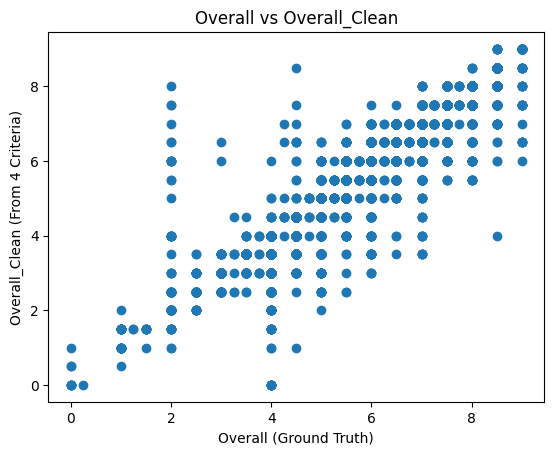

In [72]:
import matplotlib.pyplot as plt

x = df_task2_clean["Overall"]
y = df_task2_clean["Overall_Clean"]

plt.figure()

plt.scatter(x, y)

plt.xlabel("Overall (Ground Truth)")
plt.ylabel("Overall_Clean (From 4 Criteria)")
plt.title("Overall vs Overall_Clean")

plt.show()

In [73]:
len(df_task2_clean)

9782